In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [36]:
file_directory="results"
filepath = f"{file_directory}/reports/file_sizes.csv"
file_size_df = pd.read_csv(filepath)
file_size_df.sample(10)

,SRA_Number,File_Name,File_Path,Process_Name,Read_Label,Size_Byte,Size_KB,Size_MB
24,SRR11888865,SRR11888865.unclassified_2.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Contamination Output,Read_2,102214497,99818.84,97.48
82,ERR3909010,ERR3909010_1_val_1.fq,/home/b_thapamagar/BioInformatics/DataMining_H...,Quality Control Output,Read_1,43292788,42278.11,41.29
0,ERR3908797,ERR3908797.filtered.A.fq,/home/b_thapamagar/BioInformatics/DataMining_H...,Mapping Output,Read_1,4516048,4410.20,4.31
42,SRR11888912,SRR11888912_2_val_2.fq,/home/b_thapamagar/BioInformatics/DataMining_H...,Quality Control Output,Read_2,24975028,24389.68,23.82
103,ERR3908779,ERR3908779.filtered.B.fq,/home/b_thapamagar/BioInformatics/DataMining_H...,Mapping Output,Read_2,25773267,25169.21,24.58
41,ERR3909010,ERR3909010.filtered.B.fq,/home/b_thapamagar/BioInformatics/DataMining_H...,Mapping Output,Read_2,15454396,15092.18,14.74
111,SRR11888912,SRR11888912.filtered.B.fq,/home/b_thapamagar/BioInformatics/DataMining_H...,Mapping Output,Read_2,105047,102.58,0.10
28,ERR3908797,ERR3908797_2_val_2.fq,/home/b_thapamagar/BioInformatics/DataMining_H...,Quality Control Output,Read_2,8847850,8640.48,8.44
74,SRR11888898,SRR11888898_2_val_2.fq,/home/b_thapamagar/BioInformatics/DataMining_H...,Quality Control Output,Read_2,17073722,16673.56,16.28
124,ERR3909018,ERR3909018.unclassified_1.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Contamination Output,Read_1,46953868,45853.39,44.78


In [37]:
process_order = [
    "Initial Input Files",
    "Repair Read Output",
    "Quality Control Output",
    "Contamination Output",
    "Mapping Output",
]
# Create a ranking dictionary
order_map = {name: i for i, name in enumerate(process_order)}

# Add a temporary sort key column
file_size_df["_process_order"] = file_size_df["Process_Name"].map(order_map)

ordered_file_size_df = file_size_df.sort_values(
    by=["SRA_Number", "Read_Label", "_process_order"], ascending=[True, True, True]
).drop(columns=["_process_order"])
ordered_file_size_df

,SRA_Number,File_Name,File_Path,Process_Name,Read_Label,Size_Byte,Size_KB,Size_MB
19,ERR3908767,ERR3908767_1.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Initial Input Files,Read_1,142329652,138993.80,135.74
173,ERR3908767,ERR3908767_1_val_1.fq,/home/b_thapamagar/BioInformatics/DataMining_H...,Quality Control Output,Read_1,47982996,46858.39,45.76
69,ERR3908767,ERR3908767.unclassified_1.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Contamination Output,Read_1,42545250,41548.10,40.57
88,ERR3908767,ERR3908767.filtered.A.fq,/home/b_thapamagar/BioInformatics/DataMining_H...,Mapping Output,Read_1,16783294,16389.94,16.01
75,ERR3908767,ERR3908767_2.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Initial Input Files,Read_2,142329652,138993.80,135.74
...,...,...,...,...,...,...,...,...
155,SRR6245231,SRR6245231.filtered.A.fq,/home/b_thapamagar/BioInformatics/DataMining_H...,Mapping Output,Read_1,122700096,119824.31,117.02
32,SRR6245231,SRR6245231_2.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Initial Input Files,Read_2,537336024,524742.21,512.44
8,SRR6245231,SRR6245231_2_val_2.fq,/home/b_thapamagar/BioInformatics/DataMining_H...,Quality Control Output,Read_2,137410230,134189.68,131.04
150,SRR6245231,SRR6245231.unclassified_2.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Contamination Output,Read_2,124421112,121504.99,118.66


In [38]:
ordered_file_size_df["diff"] = (
    ordered_file_size_df.groupby(["SRA_Number", "Read_Label"])["Size_MB"]
    .diff(-1)
    .fillna(ordered_file_size_df["Size_MB"])
)
ordered_file_size_df["percentage_diff"] = (
    (
        ordered_file_size_df["diff"]
        / ordered_file_size_df.groupby(["SRA_Number", "Read_Label"])["diff"].transform(
            "sum"
        )
    )
    * 100
).round(2)

ordered_file_size_df["diff_after_process"] = (
    ordered_file_size_df
    .groupby(["SRA_Number", "Read_Label"])["Process_Name"]
    .shift(-1)  # get next row’s process_name within each group
    .fillna("Final remaining size for reassembly")  # if last row
)
ordered_file_size_df

,SRA_Number,File_Name,File_Path,Process_Name,Read_Label,Size_Byte,Size_KB,Size_MB,diff,percentage_diff,diff_after_process
19,ERR3908767,ERR3908767_1.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Initial Input Files,Read_1,142329652,138993.80,135.74,89.98,66.29,Quality Control Output
173,ERR3908767,ERR3908767_1_val_1.fq,/home/b_thapamagar/BioInformatics/DataMining_H...,Quality Control Output,Read_1,47982996,46858.39,45.76,5.19,3.82,Contamination Output
69,ERR3908767,ERR3908767.unclassified_1.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Contamination Output,Read_1,42545250,41548.10,40.57,24.56,18.09,Mapping Output
88,ERR3908767,ERR3908767.filtered.A.fq,/home/b_thapamagar/BioInformatics/DataMining_H...,Mapping Output,Read_1,16783294,16389.94,16.01,16.01,11.79,Final remaining size for reassembly
75,ERR3908767,ERR3908767_2.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Initial Input Files,Read_2,142329652,138993.80,135.74,89.98,66.29,Quality Control Output
...,...,...,...,...,...,...,...,...,...,...,...
155,SRR6245231,SRR6245231.filtered.A.fq,/home/b_thapamagar/BioInformatics/DataMining_H...,Mapping Output,Read_1,122700096,119824.31,117.02,117.02,22.84,Final remaining size for reassembly
32,SRR6245231,SRR6245231_2.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Initial Input Files,Read_2,537336024,524742.21,512.44,381.40,74.43,Quality Control Output
8,SRR6245231,SRR6245231_2_val_2.fq,/home/b_thapamagar/BioInformatics/DataMining_H...,Quality Control Output,Read_2,137410230,134189.68,131.04,12.38,2.42,Contamination Output
150,SRR6245231,SRR6245231.unclassified_2.fastq,/home/b_thapamagar/BioInformatics/DataMining_H...,Contamination Output,Read_2,124421112,121504.99,118.66,1.64,0.32,Mapping Output


In [40]:
pivot_df = ordered_file_size_df.pivot(
    index=["SRA_Number", "Read_Label"],
    columns="diff_after_process",
    values="percentage_diff",
)
pivot_df = pivot_df.rename(
    columns={
        "Repair Read Output": "Size reduced after repair process",
        "Quality Control Output": "Size reduced after Quality Control poccess",
        "Contamination Output": "Size reduced after Contamination Removal poccess",
        "Mapping Output": "Size reduced after Mapping poccess",
        "Remaining file Size for reassembly": "Final remaining size for reassembly",
    }
)
pivoted_difference_order = [
    "Size reduced after repair process",
    "Size reduced after Quality Control poccess",
    "Size reduced after Contamination Removal poccess",
    "Size reduced after Mapping poccess",
    "Final remaining size for reassembly",
]

existing_columns = [
    col for col in pivoted_difference_order if col in pivot_df.columns
]
pivot_df = pivot_df[existing_columns]

In [41]:
pivot_df = pivot_df.reset_index()
pivot_df

diff_after_process,SRA_Number,Read_Label,Size reduced after Quality Control poccess,Size reduced after Contamination Removal poccess,Size reduced after Mapping poccess,Final remaining size for reassembly
0,ERR3908767,Read_1,66.29,3.82,18.09,11.79
1,ERR3908767,Read_2,66.29,3.82,18.09,11.79
2,ERR3908779,Read_1,67.42,3.70,12.63,16.24
3,ERR3908779,Read_2,67.42,3.70,12.63,16.24
4,ERR3908797,Read_1,81.36,2.05,7.07,9.52
5,ERR3908797,Read_2,81.36,2.05,7.07,9.52
6,ERR3908882,Read_1,66.05,3.87,16.58,13.50
7,ERR3908882,Read_2,66.05,3.87,16.58,13.50
8,ERR3908953,Read_1,65.25,3.99,18.61,12.15
9,ERR3908953,Read_2,65.25,3.99,18.61,12.15


#### File from result

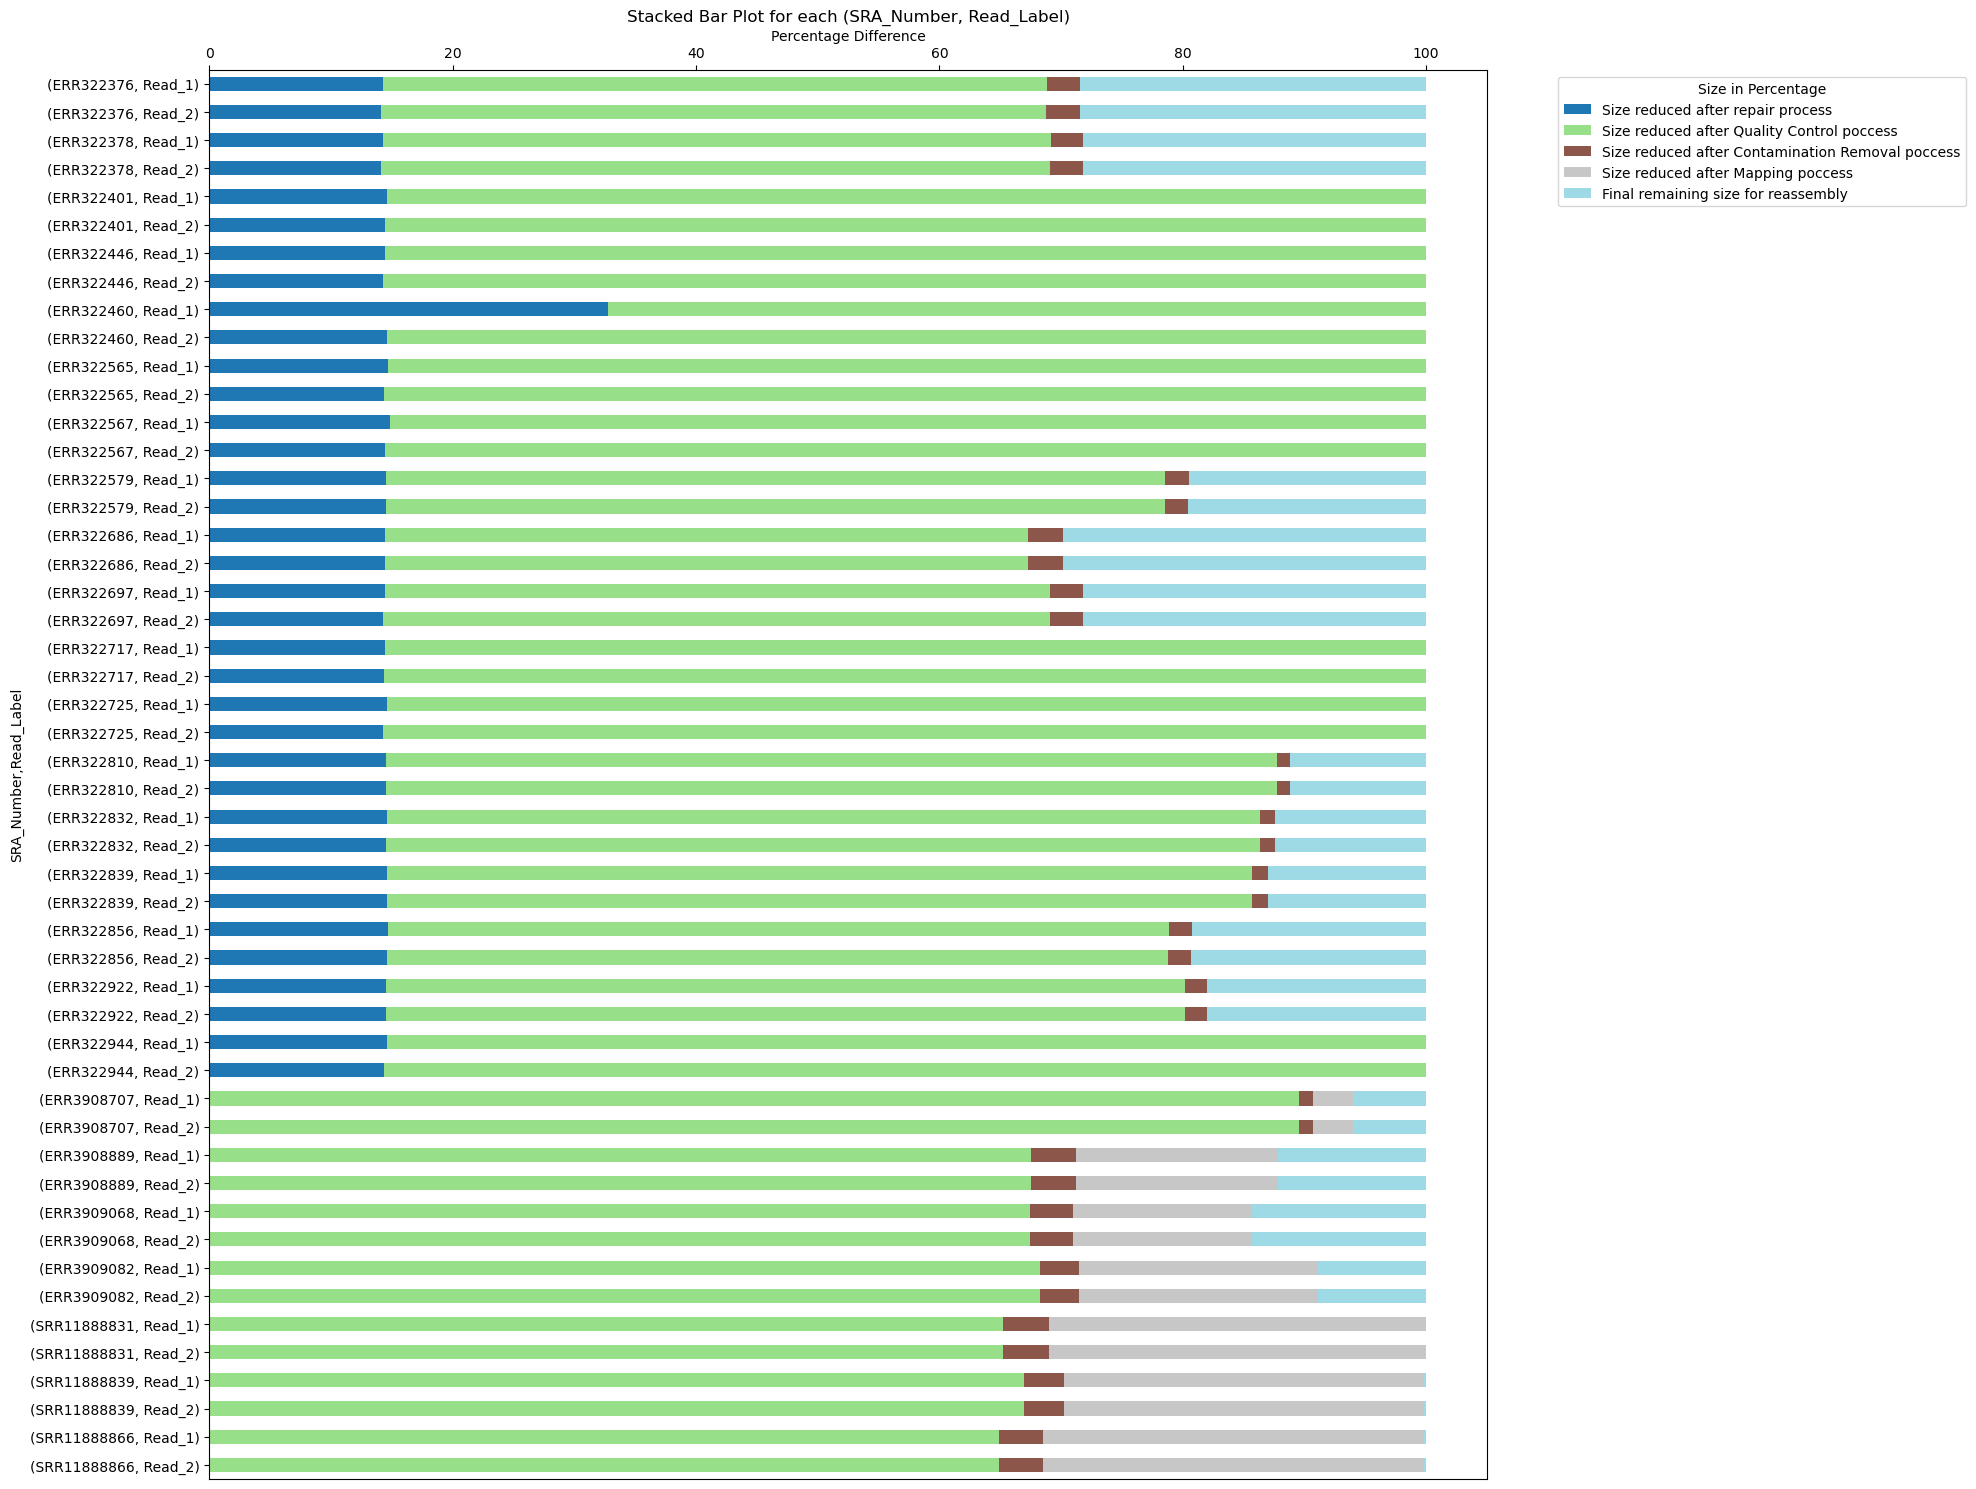

In [95]:

# Set plot size
# plt.figure(figsize=(12, 6))

# Plot stacked bar chart
ax = pivot_df.set_index(["SRA_Number", "Read_Label"]).plot(
    kind="barh",
    stacked=True,
    figsize=(20, 15),
    colormap="tab20"
)
ax.invert_yaxis()
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
plt.xlabel("Percentage Difference")
plt.title("Stacked Bar Plot for each (SRA_Number, Read_Label)")
# plt.xticks(rotation=45, ha="right")
plt.legend(title="Size in Percentage", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


#### File from nextflow_workflow/results_2025_10_28_23_14_46

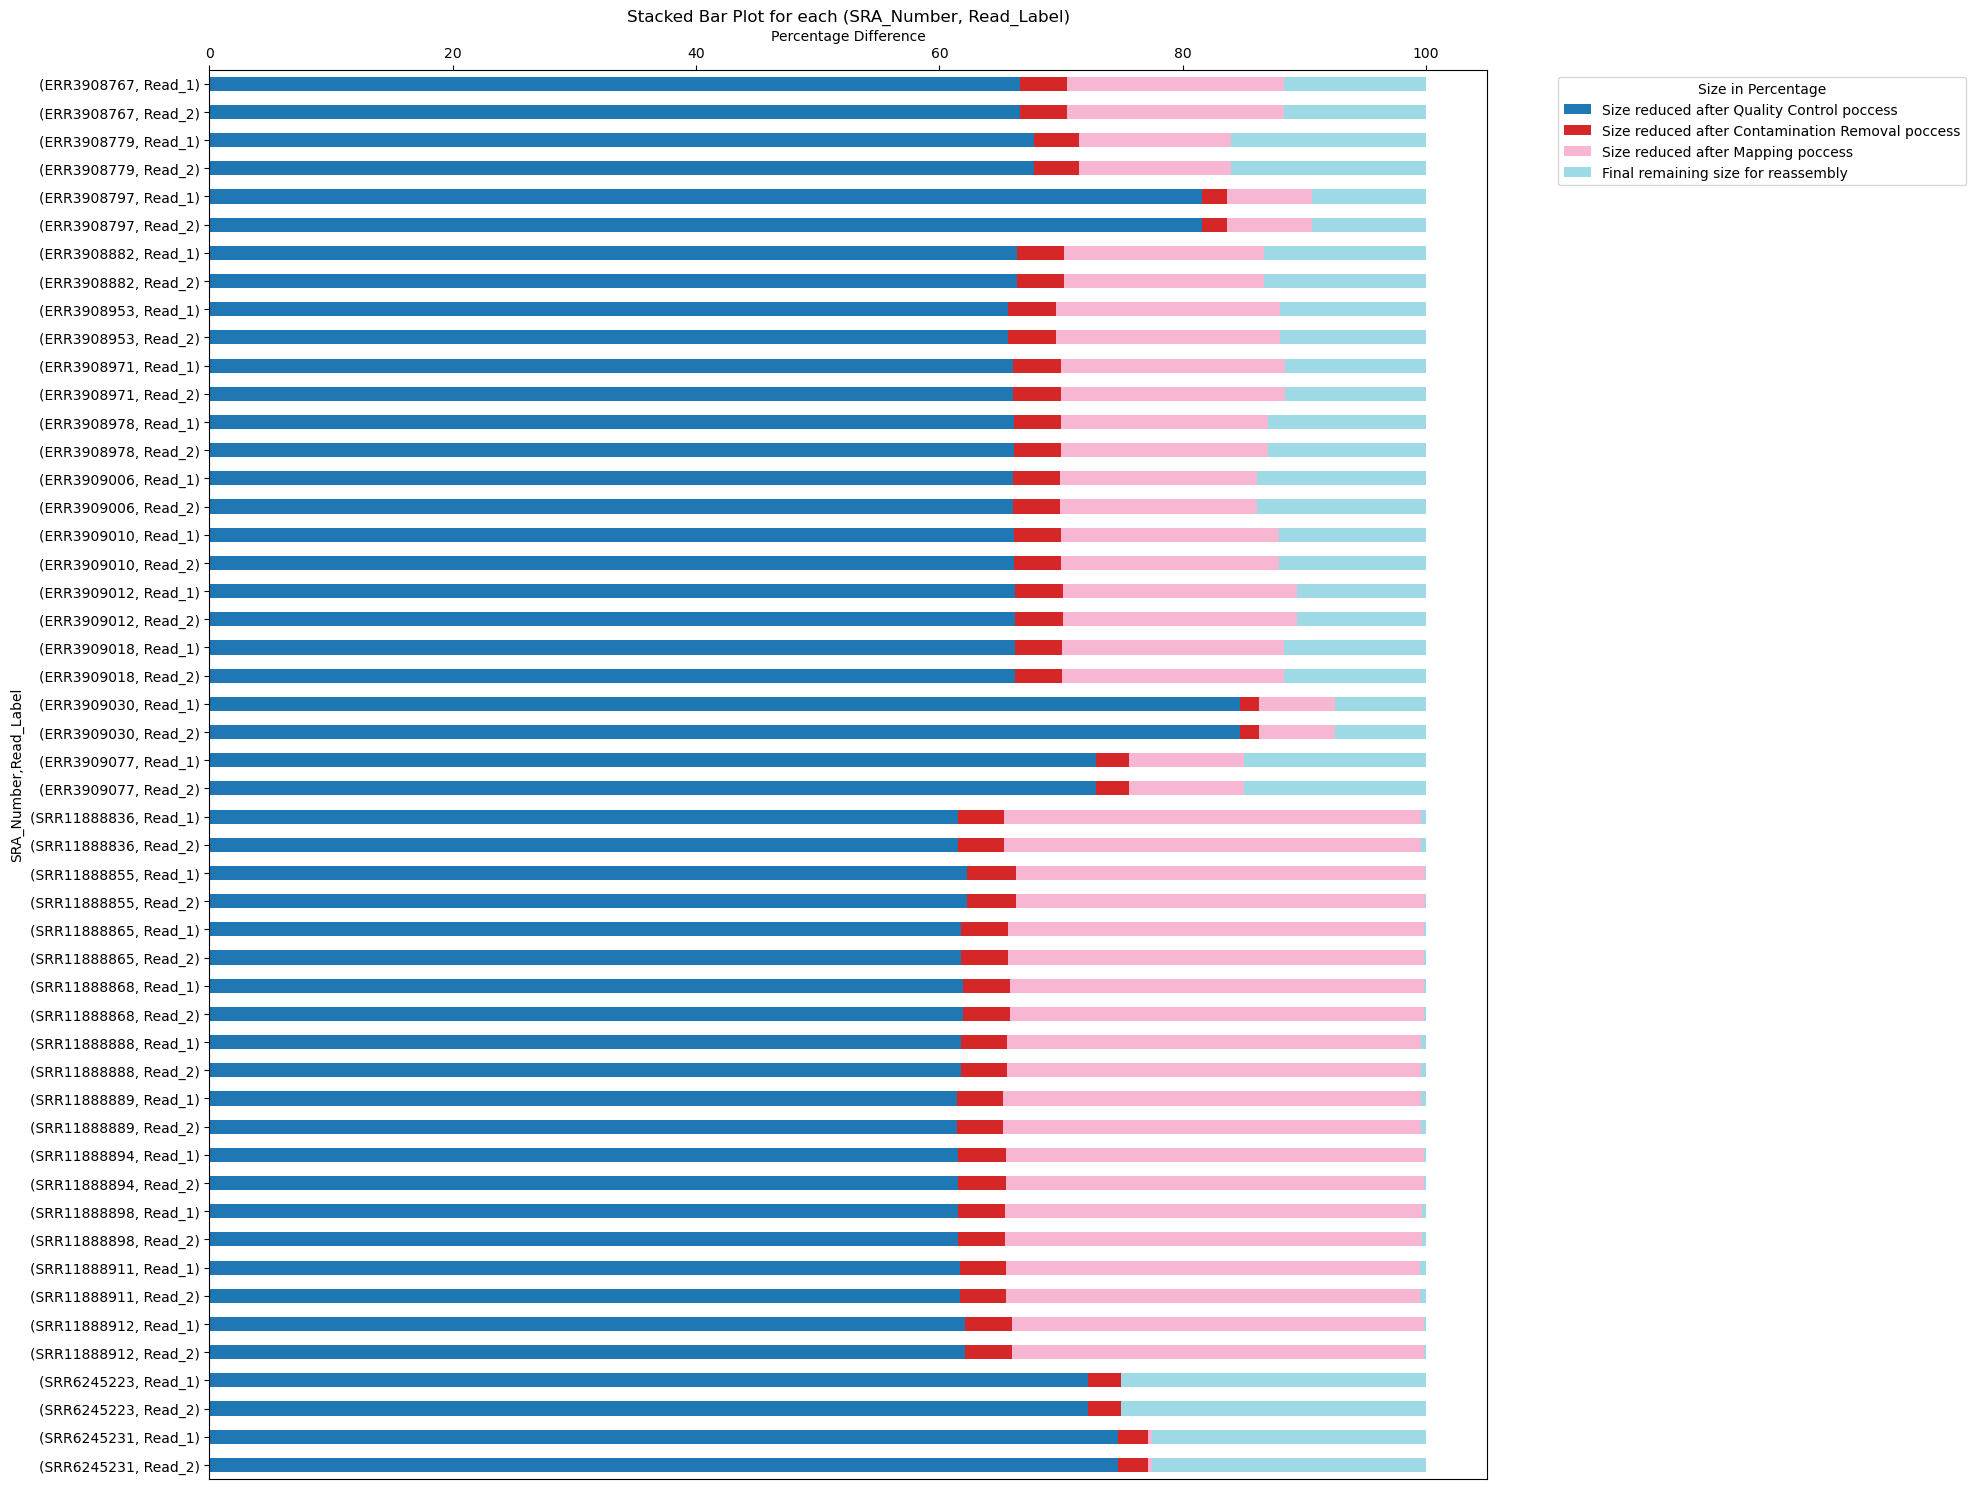

In [19]:

# Set plot size
# plt.figure(figsize=(12, 6))

# Plot stacked bar chart
ax = pivot_df.set_index(["SRA_Number", "Read_Label"]).plot(
    kind="barh",
    stacked=True,
    figsize=(20, 15),
    colormap="tab20",
    # width=0.5
)
ax.invert_yaxis()
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
plt.xlabel("Percentage Difference")
plt.title("Stacked Bar Plot for each (SRA_Number, Read_Label)")
# plt.xticks(rotation=45, ha="right")
plt.legend(title="Size in Percentage", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


##### Default configuration

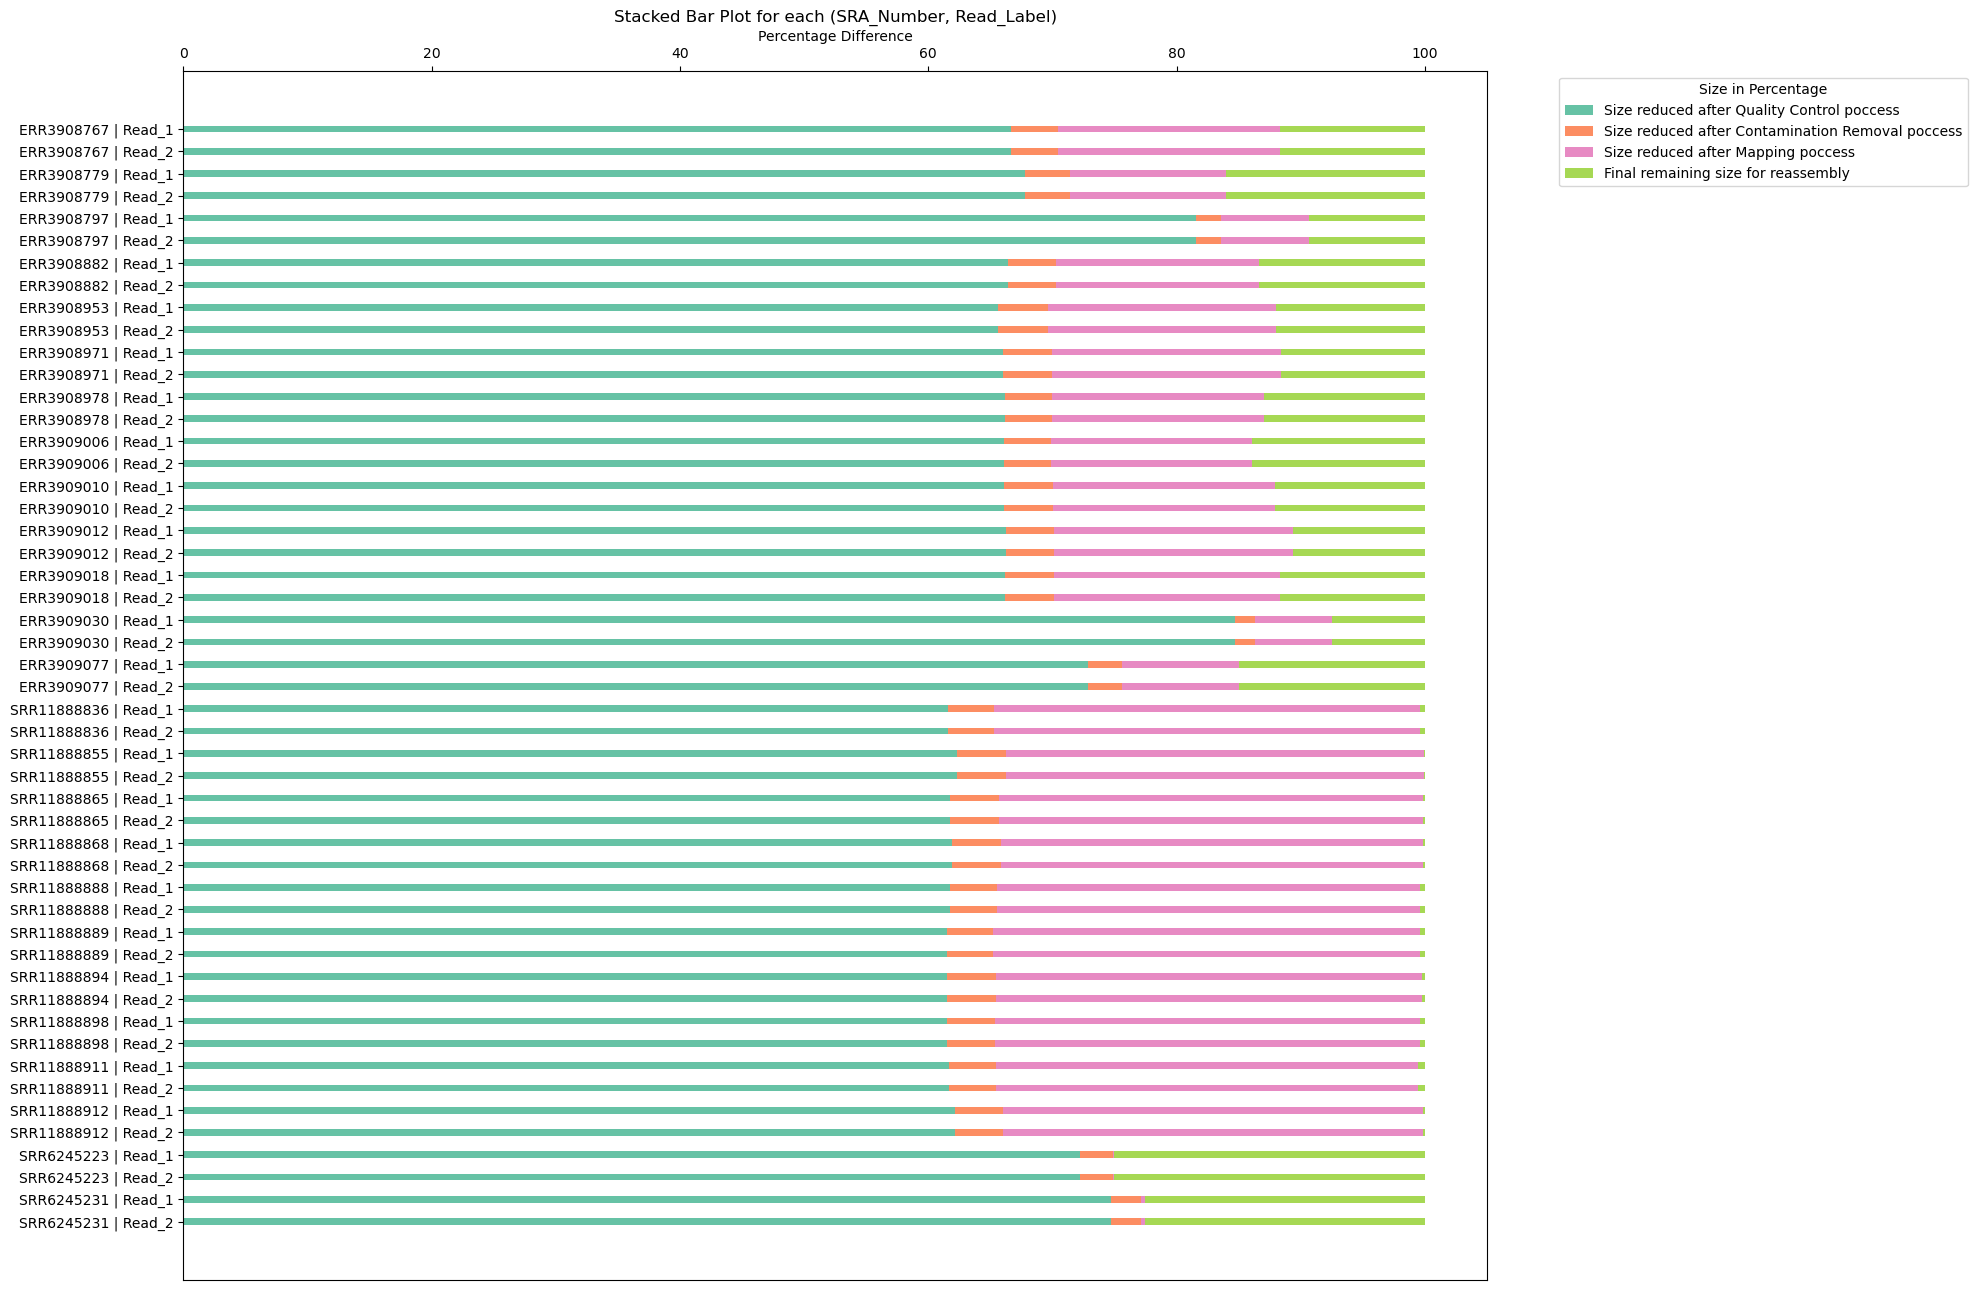

In [21]:

# # Set index
plot_pivot_df = pivot_df.set_index(['SRA_Number', 'Read_Label'])

# Prepare data
categories = plot_pivot_df.columns
index_labels = plot_pivot_df.index.tolist()#.sort()
index_labels
values = plot_pivot_df.values
values

# Positions for bars
y_pos = np.arange(len(index_labels))

# Plot
fig, ax = plt.subplots(figsize=(20, 13))
# custom_colors = ["red", "black", "green", "yellow", "blue"]
# custom_colors= ["#E41A1C", "#377EB8", "#4DAF4A", "#FF7F00", "#984EA3"]

custom_colors = ["#66C2A5", "#FC8D62", "#8DA0CB", "#E78AC3", "#A6D854"]

my_cmap = ListedColormap(custom_colors)
colors = my_cmap(np.linspace(0, 1, len(categories)))

# Draw stacked bars manually
left = np.zeros(len(index_labels))
for i, cat in enumerate(categories):
    ax.barh(y_pos, values[:, i], height=0.3, left=left, color=colors[i], label=cat)
    left += values[:, i]

# Customize
# ax.invert_yaxis()
ax.set_yticks(y_pos)
ax.set_yticklabels([f"{sra} | {read}" for sra, read in index_labels])
# ax.set_xlabel('Value')

ax.invert_yaxis()
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
plt.xlabel("Percentage Difference")
plt.title("Stacked Bar Plot for each (SRA_Number, Read_Label)")
# plt.xticks(rotation=45, ha="right")
plt.legend(title="Size in Percentage", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


##### without max_length in  quality_control

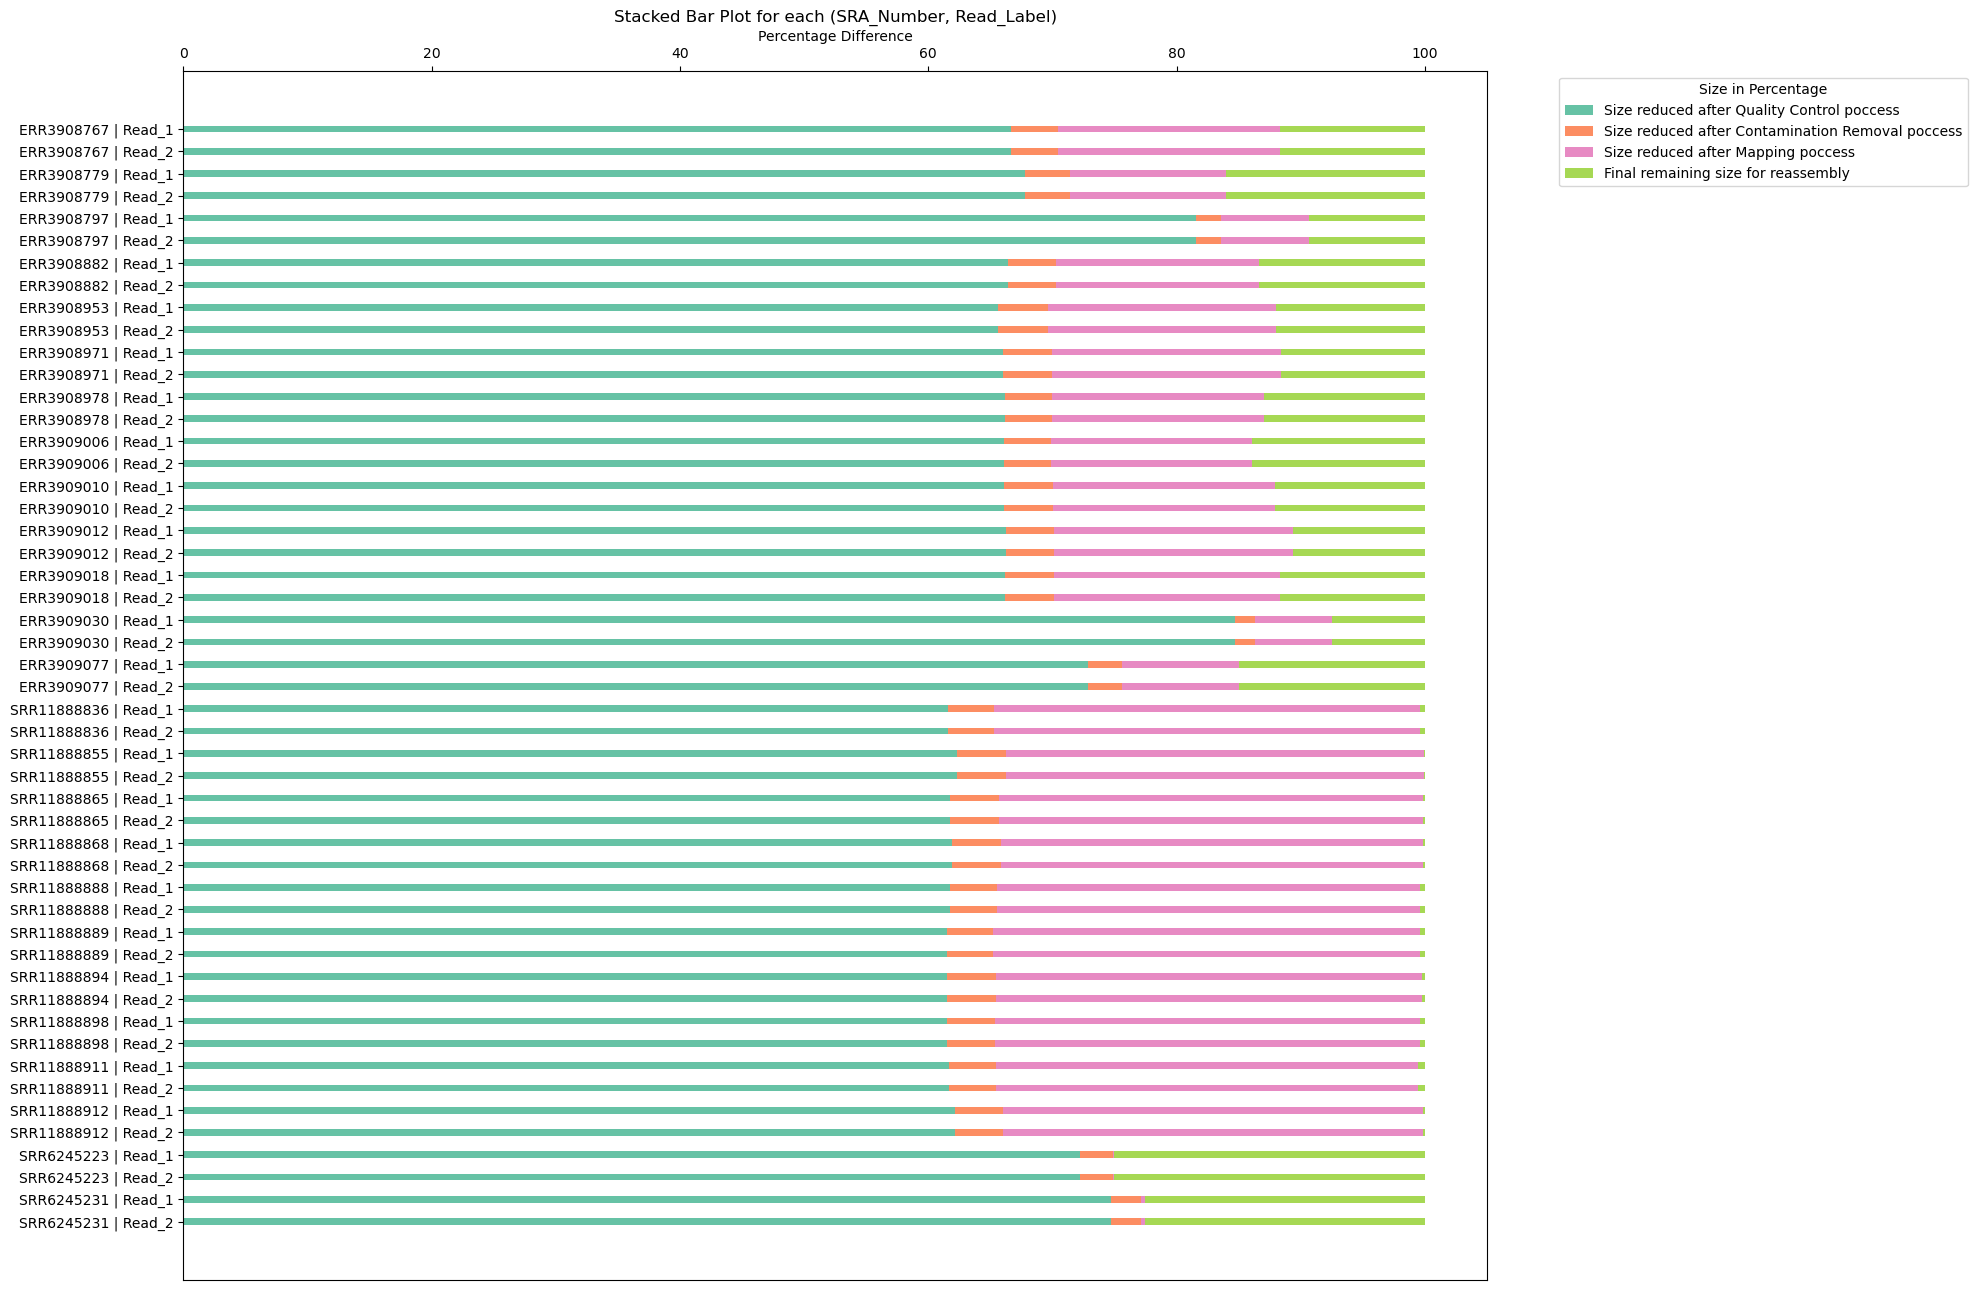

In [35]:

# # Set index
plot_pivot_df = pivot_df.set_index(['SRA_Number', 'Read_Label'])

# Prepare data
categories = plot_pivot_df.columns
index_labels = plot_pivot_df.index.tolist()#.sort()
index_labels
values = plot_pivot_df.values
values

# Positions for bars
y_pos = np.arange(len(index_labels))

# Plot
fig, ax = plt.subplots(figsize=(20, 13))
# custom_colors = ["red", "black", "green", "yellow", "blue"]
# custom_colors= ["#E41A1C", "#377EB8", "#4DAF4A", "#FF7F00", "#984EA3"]

custom_colors = ["#66C2A5", "#FC8D62", "#8DA0CB", "#E78AC3", "#A6D854"]

my_cmap = ListedColormap(custom_colors)
colors = my_cmap(np.linspace(0, 1, len(categories)))

# Draw stacked bars manually
left = np.zeros(len(index_labels))
for i, cat in enumerate(categories):
    ax.barh(y_pos, values[:, i], height=0.3, left=left, color=colors[i], label=cat)
    left += values[:, i]

# Customize
# ax.invert_yaxis()
ax.set_yticks(y_pos)
ax.set_yticklabels([f"{sra} | {read}" for sra, read in index_labels])
# ax.set_xlabel('Value')

ax.invert_yaxis()
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
plt.xlabel("Percentage Difference")
plt.title("Stacked Bar Plot for each (SRA_Number, Read_Label)")
# plt.xticks(rotation=45, ha="right")
plt.legend(title="Size in Percentage", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


##### with three_prim_clip set to 2 (3 -> 2)

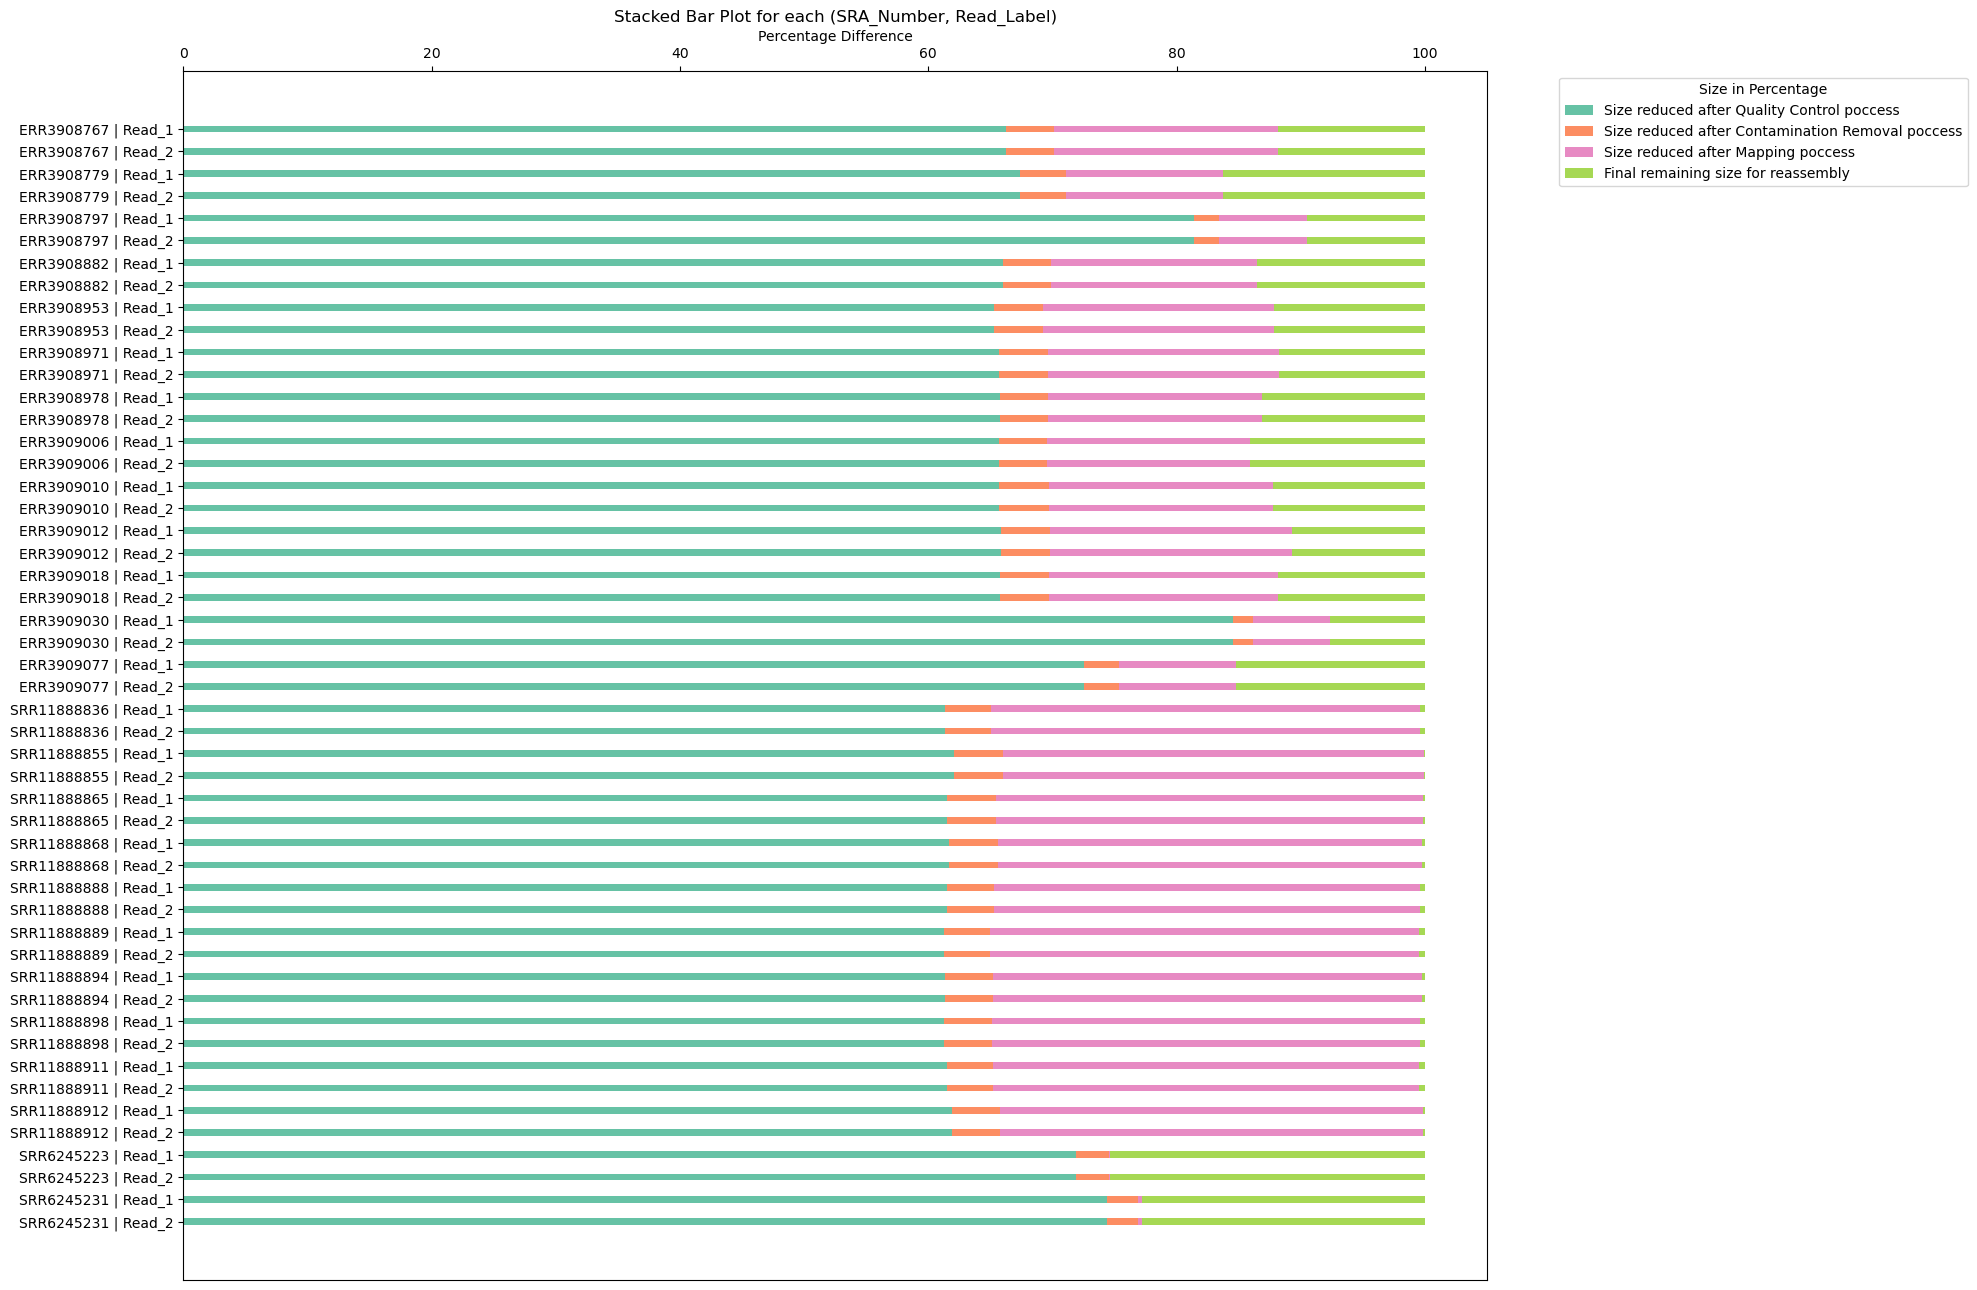

In [42]:

# # Set index
plot_pivot_df = pivot_df.set_index(['SRA_Number', 'Read_Label'])

# Prepare data
categories = plot_pivot_df.columns
index_labels = plot_pivot_df.index.tolist()#.sort()
index_labels
values = plot_pivot_df.values
values

# Positions for bars
y_pos = np.arange(len(index_labels))

# Plot
fig, ax = plt.subplots(figsize=(20, 13))
# custom_colors = ["red", "black", "green", "yellow", "blue"]
# custom_colors= ["#E41A1C", "#377EB8", "#4DAF4A", "#FF7F00", "#984EA3"]

custom_colors = ["#66C2A5", "#FC8D62", "#8DA0CB", "#E78AC3", "#A6D854"]

my_cmap = ListedColormap(custom_colors)
colors = my_cmap(np.linspace(0, 1, len(categories)))

# Draw stacked bars manually
left = np.zeros(len(index_labels))
for i, cat in enumerate(categories):
    ax.barh(y_pos, values[:, i], height=0.3, left=left, color=colors[i], label=cat)
    left += values[:, i]

# Customize
# ax.invert_yaxis()
ax.set_yticks(y_pos)
ax.set_yticklabels([f"{sra} | {read}" for sra, read in index_labels])
# ax.set_xlabel('Value')

ax.invert_yaxis()
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
plt.xlabel("Percentage Difference")
plt.title("Stacked Bar Plot for each (SRA_Number, Read_Label)")
# plt.xticks(rotation=45, ha="right")
plt.legend(title="Size in Percentage", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
